# Task 1: Data Cleaning and Preprocessing


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Data-analyst/patiala_fast_food_sales_raw.csv')

In [5]:
df.head()

,Order_ID,Order_Date,Customer_Name,Outlet,Product,Category,Quantity,Unit_Price,Payment_Method,Order_Type,Total_Sales
0,FF10001,2025-01-26,Isha,Tripuri,Classic Burger,Burgers,3.0,-99.0,UPI,Delivery,-297.0
1,FF10002,2025-04-19,Kavya,Model Town,Classic Burger,Burgers,3.0,149.0,UPI,Delivery,447.0
2,FF10003,2025-03-13,Neha,Tripuri,Veg Burger,Burgers,2.0,129.0,Card,Takeaway,258.0
3,FF10004,2025-02-28,Rohan,Leela Bhawan,Veg Burger,Burgers,4.0,129.0,Cash,Delivery,516.0
4,FF10005,2025-02-24,Rohan,Urban Estate,Margherita Pizza,Pizza,3.0,299.0,UPI,Dine-in,897.0


In [6]:
df.shape

(1220, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        1220 non-null   object 
 1   Order_Date      1220 non-null   object 
 2   Customer_Name   1210 non-null   object 
 3   Outlet          1213 non-null   object 
 4   Product         1220 non-null   object 
 5   Category        1220 non-null   object 
 6   Quantity        1214 non-null   float64
 7   Unit_Price      1214 non-null   float64
 8   Payment_Method  1212 non-null   object 
 9   Order_Type      1220 non-null   object 
 10  Total_Sales     1208 non-null   float64
dtypes: float64(3), object(8)
memory usage: 105.0+ KB


In [8]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_Name,10
Outlet,7
Product,0
Category,0
Quantity,6
Unit_Price,6
Payment_Method,8
Order_Type,0


In [9]:
df.duplicated().sum()

np.int64(20)

In [10]:
df.nunique()

,0
Order_ID,1200
Order_Date,194
Customer_Name,24
Outlet,12
Product,11
Category,4
Quantity,6
Unit_Price,12
Payment_Method,9
Order_Type,9


In [11]:
df.dtypes

,0
Order_ID,object
Order_Date,object
Customer_Name,object
Outlet,object
Product,object
Category,object
Quantity,float64
Unit_Price,float64
Payment_Method,object
Order_Type,object


In [12]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_Name,10
Outlet,7
Product,0
Category,0
Quantity,6
Unit_Price,6
Payment_Method,8
Order_Type,0


In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['Customer_Name'] = df['Customer_Name'].fillna('Unknown')
df['Outlet'] = df['Outlet'].fillna('Unknown')
df['Payment_Method'] = df['Payment_Method'].fillna('Unknown')

In [16]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

In [17]:
df['Unit_Price'] = df['Unit_Price'].fillna(
    df.groupby('Product')['Unit_Price'].transform('median')
)

In [18]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_Name,0
Outlet,0
Product,0
Category,0
Quantity,0
Unit_Price,0
Payment_Method,0
Order_Type,0


In [19]:
df['Quantity'].unique()

array([ 3.,  2.,  4.,  1., -1.,  0.])

In [20]:
df['Unit_Price'].unique()

array([-99., 149., 129., 299., 179.,  89.,  99., 349., 119., 199.,  59.,
         0.])

In [21]:
df.loc[df['Quantity'] <= 0, 'Quantity'] = df['Quantity'].median()

In [22]:
df.loc[df['Unit_Price'] <= 0, 'Unit_Price'] = df.groupby('Product')['Unit_Price'].transform('median')

In [23]:
df['Total_Sales'] = df['Quantity'] * df['Unit_Price']

In [24]:
df['Outlet'] = df['Outlet'].str.strip().str.title()

In [25]:
df['Payment_Method'] = df['Payment_Method'].str.strip().str.upper()

In [26]:
df['Order_Type'] = df['Order_Type'].str.strip().str.title()

In [27]:
df['Order_Type'] = df['Order_Type'].replace({
    'Dine In': 'Dine-In'
})

In [28]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')

/tmp/ipykernel_8005/3687525960.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')


In [29]:
df['Order_Date'].dtype

dtype('<M8[ns]')

In [30]:
df['Order_Date'].isnull().sum()

np.int64(15)

In [31]:
df['Outlet'].unique()

array(['Tripuri', 'Model Town', 'Leela Bhawan', 'Urban Estate', 'Unknown'],
      dtype=object)

In [32]:
df['Payment_Method'].unique()

array(['UPI', 'CARD', 'CASH', 'UNKNOWN'], dtype=object)

In [33]:
df['Order_Type'].unique()

array(['Delivery', 'Takeaway', 'Dine-In'], dtype=object)

In [34]:
raw_dates = pd.read_csv(
    '/content/drive/MyDrive/Data-analyst/patiala_fast_food_sales_raw.csv',
    usecols=['Order_ID', 'Order_Date']
)

In [35]:
raw_dates['Order_Date'] = pd.to_datetime(
    raw_dates['Order_Date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

In [36]:
raw_dates = raw_dates.drop_duplicates(subset='Order_ID')

df['Order_Date'] = df['Order_ID'].map(
    raw_dates.set_index('Order_ID')['Order_Date']
)

In [37]:
df['Order_Date'].isnull().sum()

np.int64(0)

In [38]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_Name,0
Outlet,0
Product,0
Category,0
Quantity,0
Unit_Price,0
Payment_Method,0
Order_Type,0


In [39]:
df['Quantity'] = df['Quantity'].astype(int)

In [40]:
df.to_csv(
    '/content/drive/MyDrive/Data-analyst/patiala_fast_food_sales_cleaned.csv',
    index=False
)

# Task 2: Exploratory Data Analysis (EDA)


In [41]:
df = pd.read_csv('/content/drive/MyDrive/Data-analyst/patiala_fast_food_sales_cleaned.csv')


In [42]:
df.describe()

,Quantity,Unit_Price,Total_Sales
count,1200.000000,1200.000000,1200.000000
mean,2.535000,159.391667,402.906667
std,1.127609,82.709112,291.943328
min,1.000000,59.000000,59.000000
25%,2.000000,99.000000,179.000000
50%,3.000000,129.000000,349.000000
75%,4.000000,199.000000,516.000000
max,4.000000,349.000000,1396.000000


In [43]:
df[['Quantity', 'Unit_Price', 'Total_Sales']].describe()

,Quantity,Unit_Price,Total_Sales
count,1200.000000,1200.000000,1200.000000
mean,2.535000,159.391667,402.906667
std,1.127609,82.709112,291.943328
min,1.000000,59.000000,59.000000
25%,2.000000,99.000000,179.000000
50%,3.000000,129.000000,349.000000
75%,4.000000,199.000000,516.000000
max,4.000000,349.000000,1396.000000


In [44]:
df['Order_ID'].nunique()

1200

In [45]:
df['Total_Sales'].sum()

np.float64(483488.0)

In [46]:
df['Total_Sales'].mean()

np.float64(402.9066666666667)

In [47]:
df.groupby('Outlet')['Total_Sales'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)


,sum,mean,count
Outlet,,,
Urban Estate,142167.0,399.345506,356
Leela Bhawan,131752.0,388.648968,339
Tripuri,105108.0,430.770492,244
Model Town,102229.0,402.476378,254
Unknown,2232.0,318.857143,7


In [48]:
df.groupby('Category')['Total_Sales'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)

,sum,mean,count
Category,,,
Pizza,163092.0,807.386139,202
Burgers,126650.0,400.791139,316
Sides,124088.0,338.114441,367
Beverages,69658.0,221.136508,315


In [49]:
df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)

,Total_Sales
Product,
Margherita Pizza,84916.0
Farmhouse Pizza,78176.0
Chicken Wings,54416.0
Cheese Burger,52735.0
Veg Burger,37410.0
Garlic Bread,36507.0
Classic Burger,36505.0
French Fries,33165.0
Cold Coffee,27846.0


In [50]:
df.groupby('Payment_Method')['Total_Sales'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)

,sum,mean,count
Payment_Method,,,
UPI,258617.0,407.913249,634
CARD,117393.0,386.161184,304
CASH,104815.0,412.657480,254
UNKNOWN,2663.0,332.875000,8


In [51]:
df.groupby('Order_Type')['Total_Sales'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)

,sum,mean,count
Order_Type,,,
Delivery,190861.0,411.338362,464
Dine-In,160311.0,392.919118,408
Takeaway,132316.0,403.402439,328


In [52]:
df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)

,Quantity
Product,
French Fries,335
Coke,321
Chicken Wings,304
Veg Burger,290
Margherita Pizza,284
Garlic Bread,283
Cheese Burger,265
Lemonade,257
Classic Burger,245


In [53]:
daily_sales = df.groupby('Order_Date')['Total_Sales'].sum()
daily_sales

,Total_Sales
Order_Date,
2025-01-01,3375.0
2025-01-02,753.0
2025-01-03,1192.0
2025-01-04,2651.0
2025-01-05,862.0
...,...
2025-06-25,2338.0
2025-06-26,3821.0
2025-06-27,2775.0


In [54]:
daily_sales.idxmax(), daily_sales.max()

('2025-03-31', 7433.0)

In [55]:
daily_sales.idxmin(), daily_sales.min()

('2025-02-20', 59.0)

In [56]:
customer_sales = df.groupby('Customer_Name')['Total_Sales'].agg(['sum', 'count', 'mean']).sort_values('sum', ascending=False)
customer_sales

,sum,count,mean
Customer_Name,,,
Rahul,27967.0,63,443.920635
Rohan,26267.0,51,515.039216
Kavya,25730.0,57,451.403509
Vikas,24801.0,57,435.105263
Tanvi,24147.0,53,455.603774
Mehak,22444.0,54,415.629630
Isha,20522.0,54,380.037037
Jaspreet,20350.0,47,432.978723
Nisha,20313.0,48,423.187500


In [57]:
customer_sales.head(10)

,sum,count,mean
Customer_Name,,,
Rahul,27967.0,63,443.920635
Rohan,26267.0,51,515.039216
Kavya,25730.0,57,451.403509
Vikas,24801.0,57,435.105263
Tanvi,24147.0,53,455.603774
Mehak,22444.0,54,415.629630
Isha,20522.0,54,380.037037
Jaspreet,20350.0,47,432.978723
Nisha,20313.0,48,423.187500


In [58]:
df.groupby('Product').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Sales=('Total_Sales', 'sum')
).sort_values('Total_Sales', ascending=False)

,Total_Quantity,Total_Sales
Product,,
Margherita Pizza,284,84916.0
Farmhouse Pizza,224,78176.0
Chicken Wings,304,54416.0
Cheese Burger,265,52735.0
Veg Burger,290,37410.0
Garlic Bread,283,36507.0
Classic Burger,245,36505.0
French Fries,335,33165.0
Cold Coffee,234,27846.0


In [59]:
df['Total_Sales'].describe()

,Total_Sales
count,1200.000000
mean,402.906667
std,291.943328
min,59.000000
25%,179.000000
50%,349.000000
75%,516.000000
max,1396.000000


In [60]:
df[['Quantity', 'Total_Sales']].corr()

,Quantity,Total_Sales
Quantity,1.000000,0.615371
Total_Sales,0.615371,1.000000


In [61]:
df[['Unit_Price', 'Total_Sales']].corr()

,Unit_Price,Total_Sales
Unit_Price,1.000000,0.710454
Total_Sales,0.710454,1.000000


<Axes: >

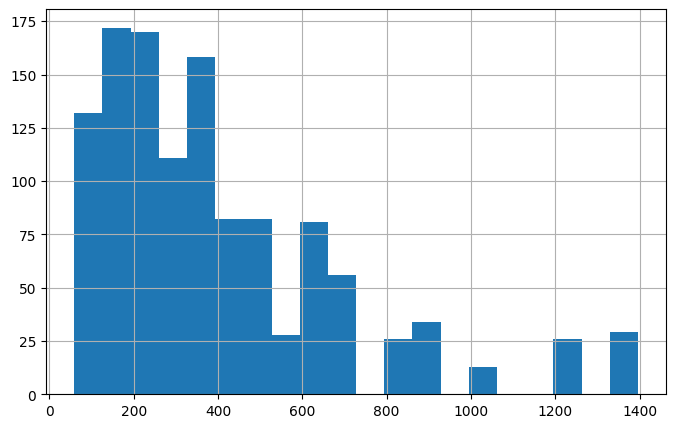

In [62]:
df['Total_Sales'].hist(bins=20, figsize=(8, 5))

<Axes: >

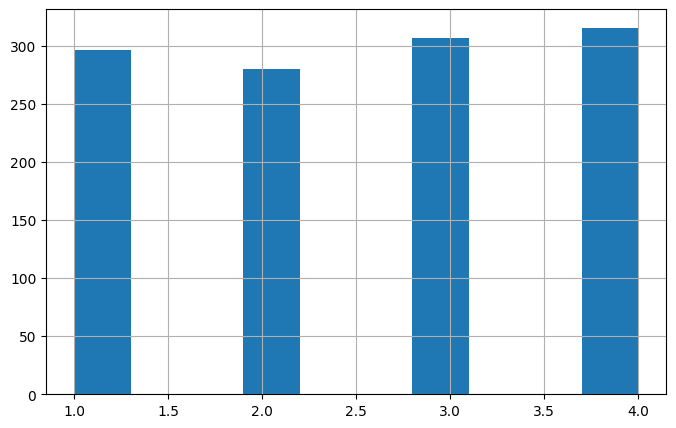

In [63]:
df['Quantity'].hist(bins=10, figsize=(8, 5))

<Axes: >

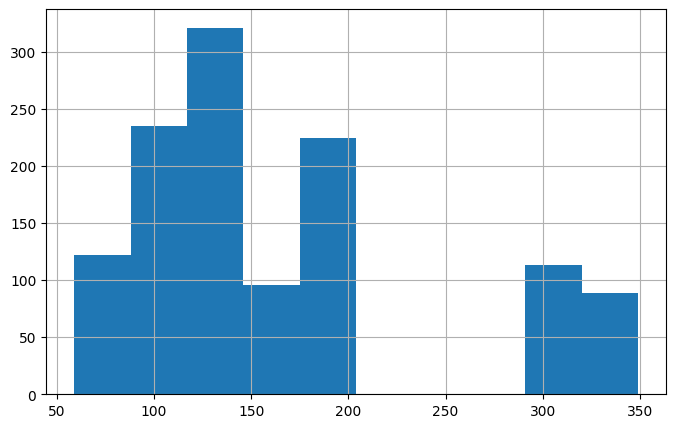

In [64]:
df['Unit_Price'].hist(bins=10, figsize=(8, 5))

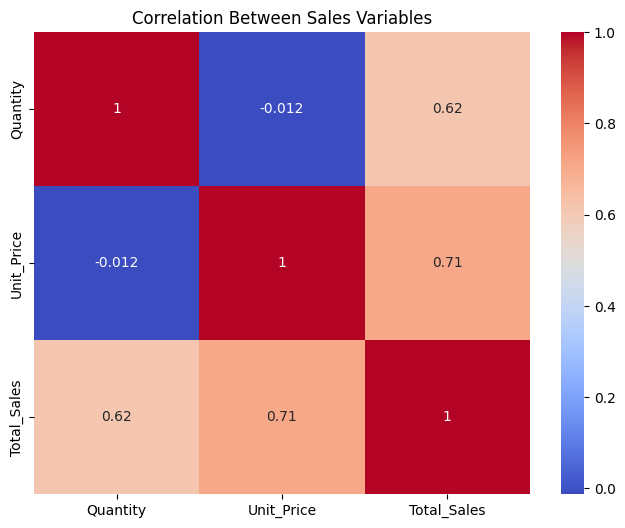

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[['Quantity', 'Unit_Price', 'Total_Sales']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Between Sales Variables')
plt.show()

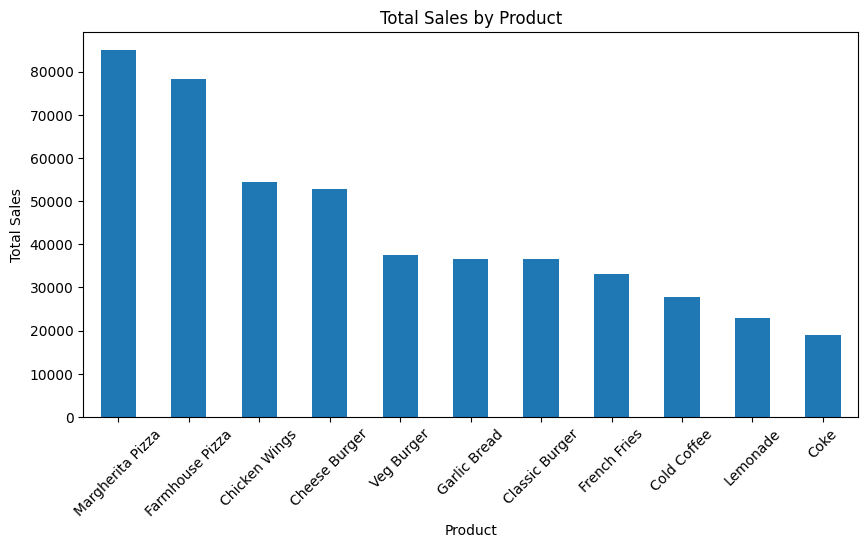

In [66]:
product_sales = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)

product_sales.plot(kind='bar', figsize=(10, 5))
plt.title('Total Sales by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

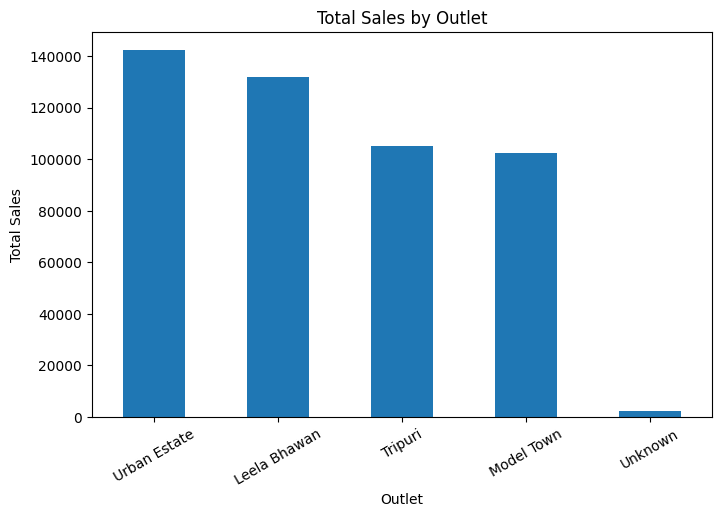

In [67]:
outlet_sales = df.groupby('Outlet')['Total_Sales'].sum().sort_values(ascending=False)

outlet_sales.plot(kind='bar', figsize=(8, 5))
plt.title('Total Sales by Outlet')
plt.xlabel('Outlet')
plt.ylabel('Total Sales')
plt.xticks(rotation=30)
plt.show()

In [68]:
Q1 = df['Total_Sales'].quantile(0.25)
Q3 = df['Total_Sales'].quantile(0.75)
IQR = Q3 - Q1

In [69]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [70]:
outliers = df[
    (df['Total_Sales'] < lower_limit) |
    (df['Total_Sales'] > upper_limit)
]

len(outliers)

68

In [71]:
df.groupby('Product')['Quantity'].sum().idxmax()

'French Fries'

In [72]:
df.groupby('Outlet')['Total_Sales'].sum().idxmax()

'Urban Estate'

In [73]:
df.groupby('Category')['Total_Sales'].sum().idxmax()

'Pizza'

# Task 3: Data Visualization Dashboard

In [74]:
import matplotlib.pyplot as plt

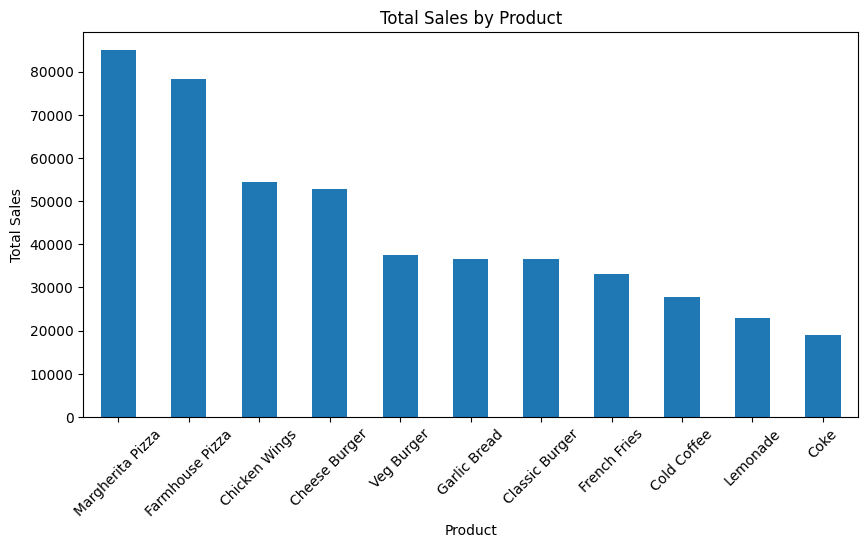

In [75]:
product_sales = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)

product_sales.plot(kind='bar', figsize=(10, 5))
plt.title('Total Sales by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

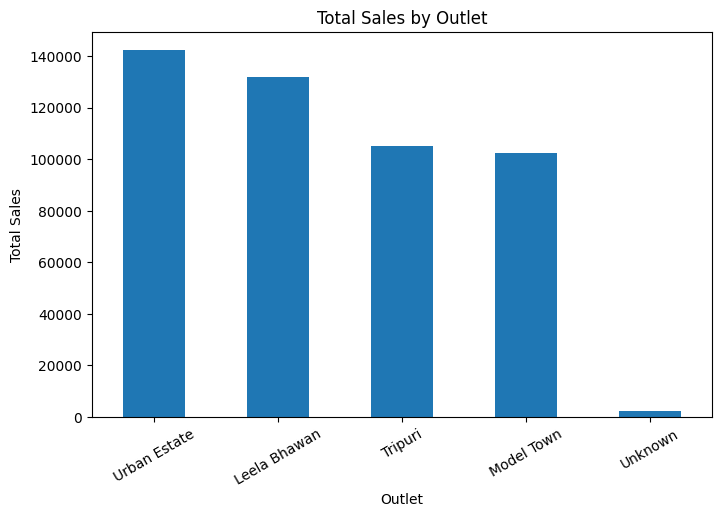

In [76]:
outlet_sales = df.groupby('Outlet')['Total_Sales'].sum().sort_values(ascending=False)

outlet_sales.plot(kind='bar', figsize=(8, 5))
plt.title('Total Sales by Outlet')
plt.xlabel('Outlet')
plt.ylabel('Total Sales')
plt.xticks(rotation=30)
plt.show()

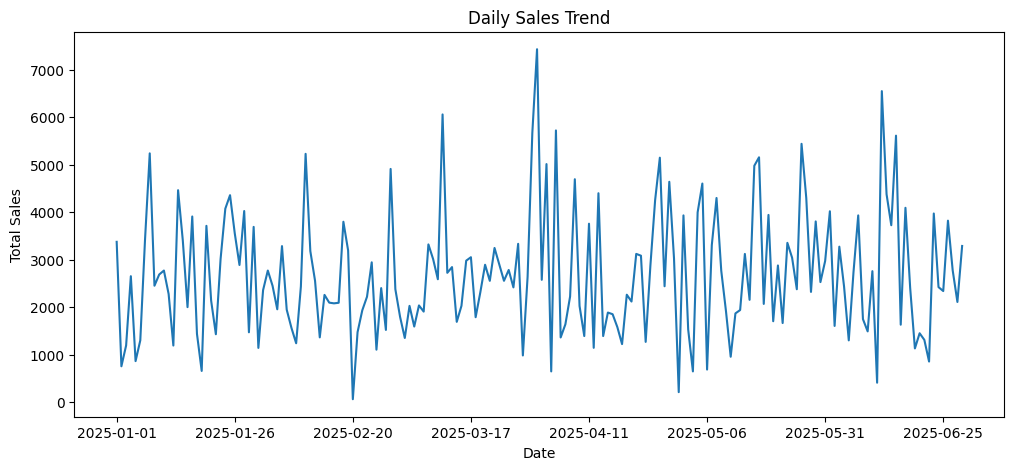

In [77]:
daily_sales = df.groupby('Order_Date')['Total_Sales'].sum()

daily_sales.plot(figsize=(12, 5))
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

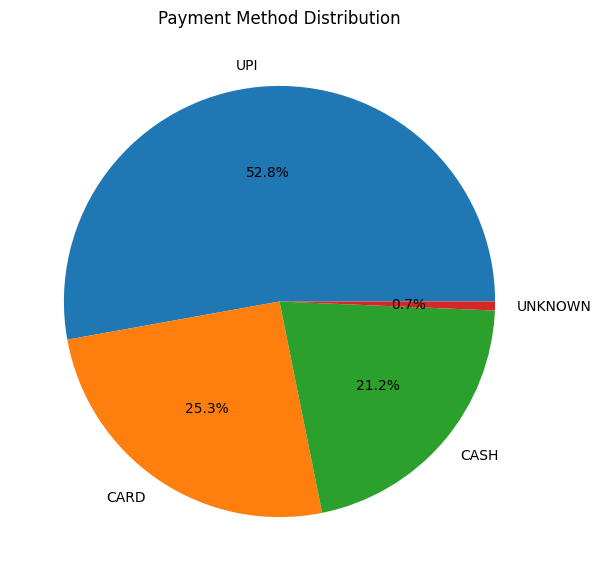

In [78]:
payment_counts = df['Payment_Method'].value_counts()

payment_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(7, 7))
plt.title('Payment Method Distribution')
plt.ylabel('')
plt.show()

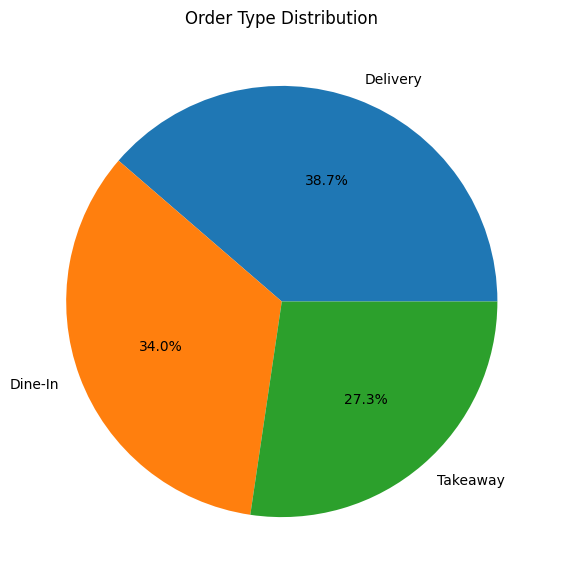

In [79]:
order_type_counts = df['Order_Type'].value_counts()

order_type_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(7, 7))
plt.title('Order Type Distribution')
plt.ylabel('')
plt.show()

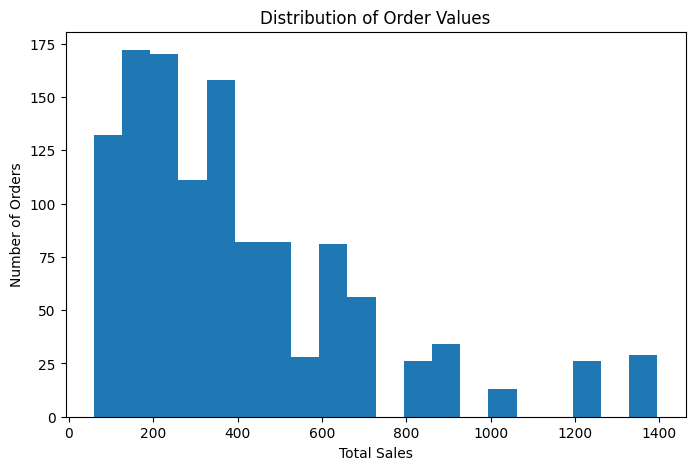

In [80]:
df['Total_Sales'].plot(kind='hist', bins=20, figsize=(8, 5))
plt.title('Distribution of Order Values')
plt.xlabel('Total Sales')
plt.ylabel('Number of Orders')
plt.show()

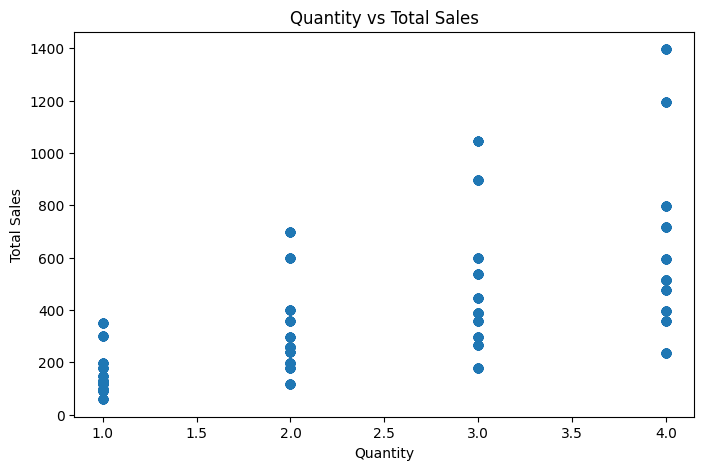

In [81]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Quantity'], df['Total_Sales'])
plt.title('Quantity vs Total Sales')
plt.xlabel('Quantity')
plt.ylabel('Total Sales')
plt.show()

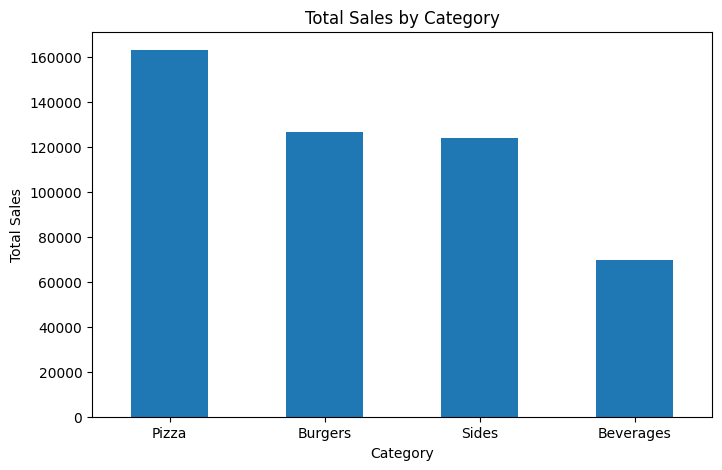

In [82]:
category_sales = df.groupby('Category')['Total_Sales'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar', figsize=(8, 5))
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

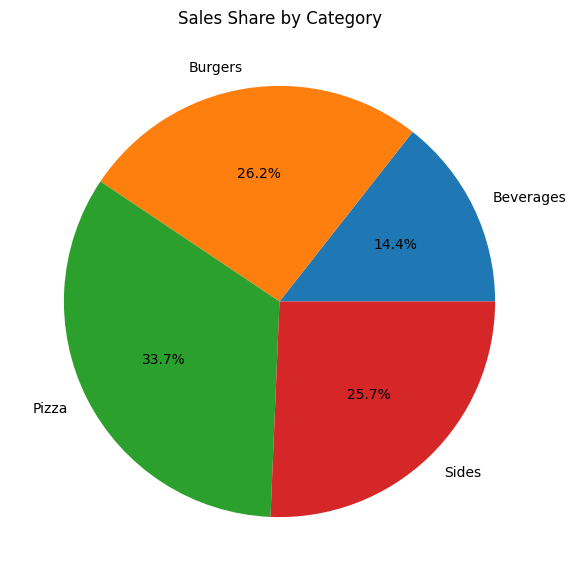

In [83]:
category_sales = df.groupby('Category')['Total_Sales'].sum()

category_sales.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7, 7)
)

plt.title('Sales Share by Category')
plt.ylabel('')
plt.show()

# Task 4: Customer Data Analysis

In [84]:
customer_analysis = df.groupby('Customer_Name').agg(
    Total_Orders=('Order_ID', 'count'),
    Total_Spending=('Total_Sales', 'sum'),
    Average_Order_Value=('Total_Sales', 'mean')
).sort_values('Total_Spending', ascending=False)

In [85]:
customer_analysis.head(10)

,Total_Orders,Total_Spending,Average_Order_Value
Customer_Name,,,
Rahul,63,27967.0,443.920635
Rohan,51,26267.0,515.039216
Kavya,57,25730.0,451.403509
Vikas,57,24801.0,435.105263
Tanvi,53,24147.0,455.603774
Mehak,54,22444.0,415.629630
Isha,54,20522.0,380.037037
Jaspreet,47,20350.0,432.978723
Nisha,48,20313.0,423.187500


In [86]:
customer_analysis.sort_values('Total_Orders', ascending=False).head(10)

,Total_Orders,Total_Spending,Average_Order_Value
Customer_Name,,,
Rahul,63,27967.0,443.920635
Kavya,57,25730.0,451.403509
Vikas,57,24801.0,435.105263
Karan,55,20015.0,363.909091
Isha,54,20522.0,380.037037
Mehak,54,22444.0,415.629630
Tanvi,53,24147.0,455.603774
Aditya,52,18382.0,353.500000
Rohan,51,26267.0,515.039216


In [87]:
customer_analysis['Customer_Segment'] = pd.qcut(
    customer_analysis['Total_Spending'],
    q=3,
    labels=['Low Value', 'Regular', 'High Value']
)

In [88]:
customer_analysis.groupby('Customer_Segment', observed=True).agg(
    Customers=('Total_Orders', 'count'),
    Average_Spending=('Total_Spending', 'mean'),
    Average_Orders=('Total_Orders', 'mean')
)

,Customers,Average_Spending,Average_Orders
Customer_Segment,,,
Low Value,9,15117.777778,41.222222
Regular,8,19400.000000,49.125000
High Value,8,24028.500000,54.500000


In [89]:
customer_analysis.groupby('Customer_Segment', observed=True)['Total_Spending'].sum()

,Total_Spending
Customer_Segment,
Low Value,136060.0
Regular,155200.0
High Value,192228.0


In [90]:
customer_order_type = pd.crosstab(
    df['Customer_Name'],
    df['Order_Type']
)

customer_order_type.head(10)

Order_Type,Delivery,Dine-In,Takeaway
Customer_Name,,,
Aditya,21,18,13
Aman,19,21,7
Ananya,13,23,14
Arjun,19,19,12
Gurpreet,21,11,13
Harsh,19,19,11
Isha,22,14,18
Jaspreet,24,10,13
Karan,20,24,11


In [91]:
df.groupby('Order_Type')['Total_Sales'].agg(
    Total_Spending='sum',
    Average_Order_Value='mean',
    Number_of_Orders='count'
)

,Total_Spending,Average_Order_Value,Number_of_Orders
Order_Type,,,
Delivery,190861.0,411.338362,464
Dine-In,160311.0,392.919118,408
Takeaway,132316.0,403.402439,328


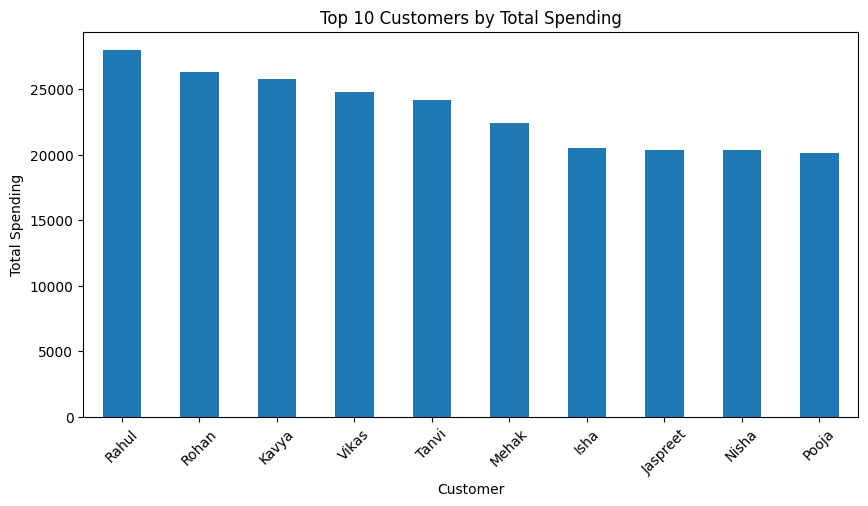

In [92]:
top_customers = customer_analysis.head(10)

top_customers['Total_Spending'].plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Top 10 Customers by Total Spending')
plt.xlabel('Customer')
plt.ylabel('Total Spending')
plt.xticks(rotation=45)
plt.show()

In [93]:
customer_analysis['Customer_Segment'].value_counts()

,count
Customer_Segment,
Low Value,9
Regular,8
High Value,8


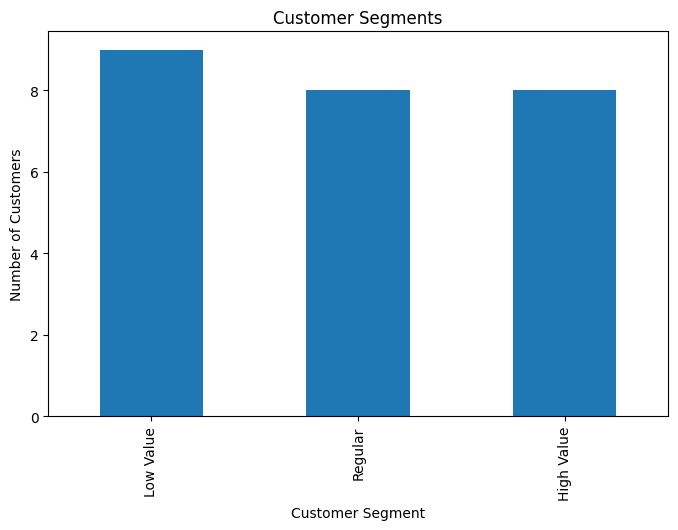

In [94]:
customer_analysis['Customer_Segment'].value_counts().plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.show()

In [95]:
customer_analysis.sort_values(
    'Average_Order_Value',
    ascending=False
).head(10)

,Total_Orders,Total_Spending,Average_Order_Value,Customer_Segment
Customer_Name,,,,
Unknown,10,6537.0,653.700000,Low Value
Rohan,51,26267.0,515.039216,High Value
Pooja,41,20144.0,491.317073,Regular
Tanvi,53,24147.0,455.603774,High Value
Kavya,57,25730.0,451.403509,High Value
Rahul,63,27967.0,443.920635,High Value
Vikas,57,24801.0,435.105263,High Value
Jaspreet,47,20350.0,432.978723,High Value
Nisha,48,20313.0,423.187500,Regular


In [96]:
segment_summary = customer_analysis.groupby(
    'Customer_Segment',
    observed=True
).agg(
    Customers=('Total_Orders', 'count'),
    Total_Spending=('Total_Spending', 'sum'),
    Average_Spending=('Total_Spending', 'mean')
)

segment_summary

,Customers,Total_Spending,Average_Spending
Customer_Segment,,,
Low Value,9,136060.0,15117.777778
Regular,8,155200.0,19400.000000
High Value,8,192228.0,24028.500000


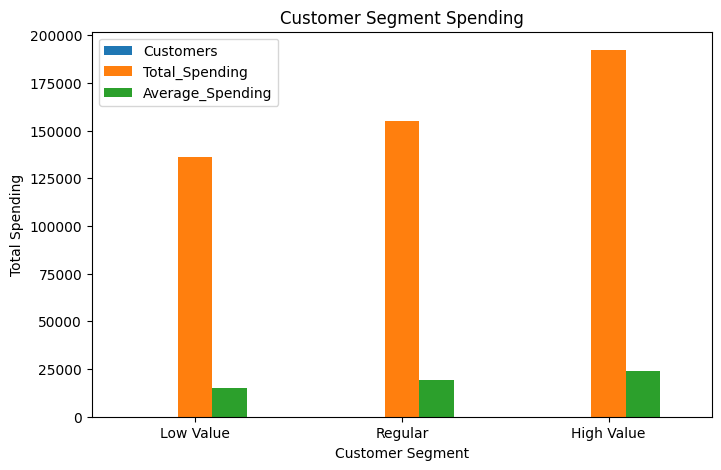

In [97]:
segment_summary.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Customer Segment Spending')
plt.xlabel('Customer Segment')
plt.ylabel('Total Spending')
plt.xticks(rotation=0)
plt.show()

In [98]:
customer_analysis.head(10)

,Total_Orders,Total_Spending,Average_Order_Value,Customer_Segment
Customer_Name,,,,
Rahul,63,27967.0,443.920635,High Value
Rohan,51,26267.0,515.039216,High Value
Kavya,57,25730.0,451.403509,High Value
Vikas,57,24801.0,435.105263,High Value
Tanvi,53,24147.0,455.603774,High Value
Mehak,54,22444.0,415.629630,High Value
Isha,54,20522.0,380.037037,High Value
Jaspreet,47,20350.0,432.978723,High Value
Nisha,48,20313.0,423.187500,Regular
